# TP 1 : Premiers Embeddings

## Objectif

Explorer les embeddings et la similarité sémantique pour comprendre comment les modèles capturent le sens des phrases.

---
## Partie 1 : Installation et Configuration

### Tâche 1.1 : Installer les dépendances nécessaires

Installez les bibliothèques suivantes :
- `sentence-transformers` : pour les modèles d'embedding
- `matplotlib` : pour la visualisation
- `seaborn` : pour les heatmaps
- `numpy` : pour les calculs matriciels

In [40]:
# TODO : Installer les dépendances
# Décommentez et exécutez cette cellule
# !pip install sentence-transformers matplotlib seaborn numpy

### Tâche 1.2 : Importer les bibliothèques

In [41]:
# TODO : Importer les bibliothèques nécessaires
# - SentenceTransformer de sentence_transformers
# - numpy
# - matplotlib.pyplot
# - seaborn
# - cosine_similarity de sklearn.metrics.pairwise

from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import time

---
## Partie 2 : Encoder des Phrases

### Tâche 2.1 : Préparer les données

Nous allons travailler avec 10 phrases en français couvrant différents sujets.

In [42]:
phrases = [
    "Le soleil brille dans le ciel bleu",
    "Il fait beau aujourd'hui avec un ciel dégagé",
    "La pluie tombe depuis ce matin",
    "Python est utilisé pour le machine learning",
    "L'apprentissage automatique utilise souvent Python",
    "Je vais au supermarché acheter des légumes",
    "Elle fait ses courses au marché",
    "Le chat dort paisiblement sur le canapé",
    "Mon félin se repose sur le sofa",
    "La voiture rouge est garée devant la maison",
]

print(f"Nombre de phrases : {len(phrases)}")
for i, phrase in enumerate(phrases, 1):
    print(f"{i}. {phrase}")

Nombre de phrases : 10
1. Le soleil brille dans le ciel bleu
2. Il fait beau aujourd'hui avec un ciel dégagé
3. La pluie tombe depuis ce matin
4. Python est utilisé pour le machine learning
5. L'apprentissage automatique utilise souvent Python
6. Je vais au supermarché acheter des légumes
7. Elle fait ses courses au marché
8. Le chat dort paisiblement sur le canapé
9. Mon félin se repose sur le sofa
10. La voiture rouge est garée devant la maison


### Tâche 2.2 : Charger le modèle d'embedding

Chargez le modèle `all-MiniLM-L6-v2` qui est léger et performant pour le français.

In [43]:
# TODO : Charger le modèle 'all-MiniLM-L6-v2'
model_l6 = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12702.16it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Tâche 2.3 : Encoder les phrases

Utilisez le modèle pour transformer chaque phrase en vecteur d'embedding.

In [44]:
# TODO : Encoder les phrases
t0 = time.time()
embeddings_l6 = model_l6.encode(phrases)
vectorization_time_l6 = time.time() - t0

# Vérifiez la forme des embeddings
print(f"Forme des embeddings : {embeddings_l6.shape}")
print(f"Dimension d'un embedding : {embeddings_l6.shape[1]}")

Forme des embeddings : (10, 384)
Dimension d'un embedding : 384


---
## Partie 3 : Calculer la Matrice de Similarité 

### Tâche 3.1 : Calculer la similarité cosinus

Calculez la matrice de similarité 10x10 entre toutes les paires de phrases.

In [45]:
# TODO : Calculer la matrice de similarité cosinus
similarity_matrix_l6 = cosine_similarity(embeddings_l6)

# Afficher la forme et un aperçu
print(f"Forme de la matrice : {similarity_matrix_l6.shape}")
print(f"\nPremières valeurs :\n{similarity_matrix_l6[:3, :3]}")

Forme de la matrice : (10, 10)

Premières valeurs :
[[0.9999999  0.4760921  0.35655946]
 [0.4760921  1.0000002  0.44713685]
 [0.35655946 0.44713685 1.0000001 ]]


### Tâche 3.2 : Identifier les paires les plus similaires

Trouvez les 5 paires de phrases ayant les scores de similarité les plus élevés (en excluant la diagonale qui compare une phrase avec elle-même).

In [46]:
# TODO : Trouver les 5 paires les plus similaires
# Indices :
# 1. Créer une copie de la matrice
# 2. Mettre la diagonale à -1 pour l'ignorer
# 3. Trouver les indices des 5 valeurs maximales
# 4. Afficher les paires avec leurs scores


def topk_triangle_inf(
    similarities: np.ndarray, topk: int = 5
) -> list[tuple[np.ndarray, np.ndarray]]:
    m = similarities.copy()
    np.fill_diagonal(m, -1)
    m[np.triu_indices_from(m, k=1)] = -1
    flat_indices = np.argpartition(m.ravel(), -topk)[-topk:]
    flat_indices = flat_indices[np.argsort(m.ravel()[flat_indices])[::-1]]
    lignes, colonnes = np.unravel_index(flat_indices, m.shape)
    return list(zip(lignes, colonnes))


topk_similarities_l6 = topk_triangle_inf(similarity_matrix_l6)
print(f"{'Score':<5} | {'Phrase 1':<50} | {'Phrase 2':<50}")
for row, column in topk_similarities_l6:
    print(
        f"{similarity_matrix_l6[row, column]:<5.2f} | {phrases[row]:<50} | {phrases[column]:<50}"
    )

Score | Phrase 1                                           | Phrase 2                                          
0.56  | L'apprentissage automatique utilise souvent Python | Python est utilisé pour le machine learning       
0.51  | Elle fait ses courses au marché                    | Il fait beau aujourd'hui avec un ciel dégagé      
0.49  | Mon félin se repose sur le sofa                    | Le chat dort paisiblement sur le canapé           
0.48  | Il fait beau aujourd'hui avec un ciel dégagé       | Le soleil brille dans le ciel bleu                
0.47  | Je vais au supermarché acheter des légumes         | Il fait beau aujourd'hui avec un ciel dégagé      


---
## Partie 4 : Visualisation 

### Tâche 4.1 : Créer une heatmap

Visualisez la matrice de similarité avec une heatmap pour mieux comprendre les relations entre phrases.

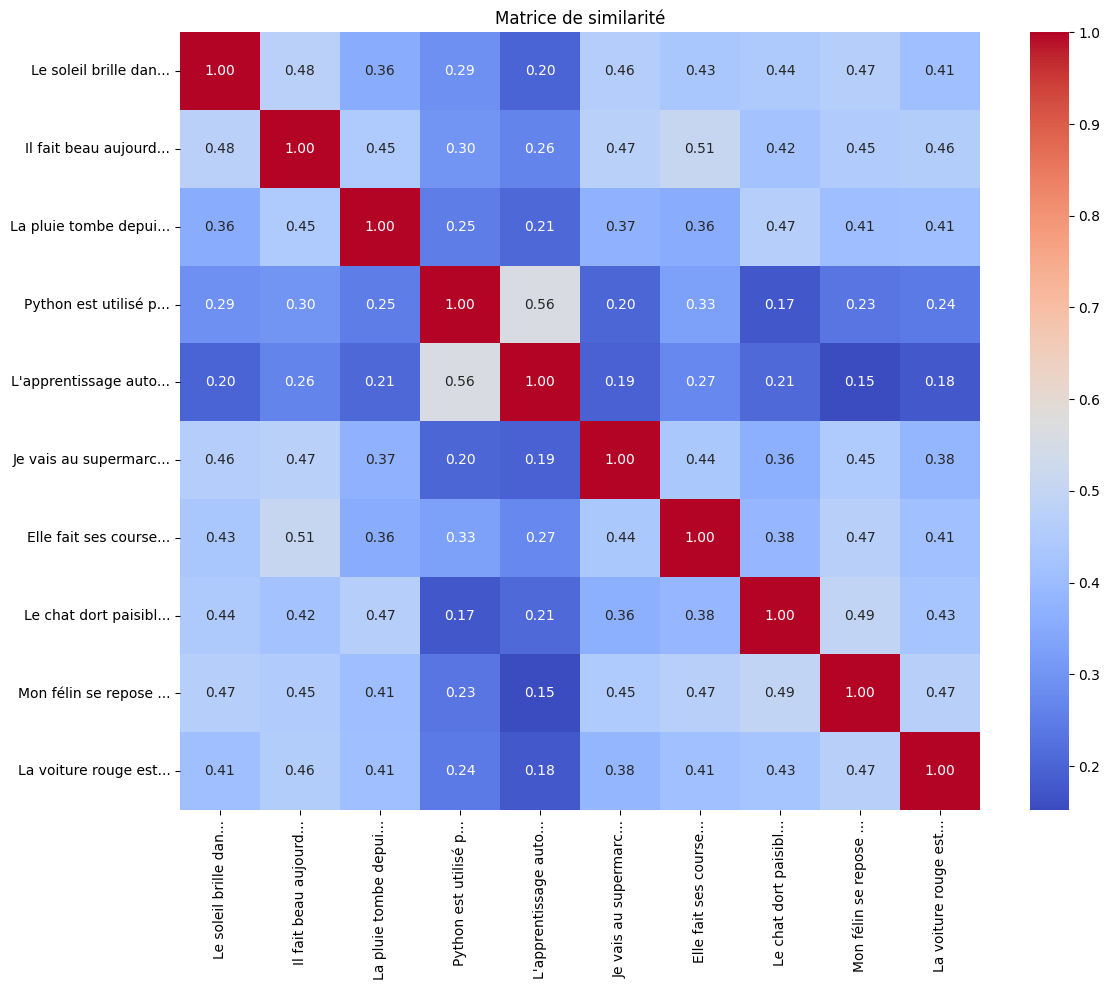

In [47]:
# TODO : Créer une heatmap avec seaborn
# Indices :
# - Utiliser seaborn.heatmap()
# - Paramètres recommandés : annot=True, fmt='.2f', cmap='coolwarm'
# - Ajouter des labels pour les axes
# - Définir une taille de figure appropriée (ex: 12x10)

plt.figure(figsize=(12, 10))
labels = [t[:20] + "..." for t in phrases]

sns.heatmap(
    similarity_matrix_l6,
    annot=True,
    fmt="0.2f",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels,
)

plt.title("Matrice de similarité")
plt.tight_layout()
plt.show()

---
## Partie 5 : Comparaison de Modèles 

### Tâche 5.1 : Tester un autre modèle

Testez le modèle `paraphrase-multilingual-MiniLM-L12-v2` et comparez les résultats.

Modèles suggérés :
- `paraphrase-multilingual-MiniLM-L12-v2` (bon pour le français)
- `distiluse-base-multilingual-cased-v2`
- `all-mpnet-base-v2` (anglais uniquement mais très performant)

In [48]:
# TODO : Charger un second modèle et comparer
# 1. Charger le nouveau modèle
# 2. Encoder les mêmes phrases
# 3. Calculer la matrice de similarité
# 4. Comparer les scores des paires les plus similaires

model_l12 = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
t0 = time.time()
embeddings_l12 = model_l12.encode(phrases)
vectorization_time_l12 = time.time() - t0
similarity_matrix_l12 = cosine_similarity(embeddings_l12)
topk_similarities_l12 = topk_triangle_inf(similarity_matrix_l12)

print(f"\nVector shape :")
print(f"  L6  : {model_l6.get_embedding_dimension()}")
print(f"  L12 : {model_l12.get_embedding_dimension()}")

print(f"\nTemps d'inférence :")
print(f"  L6  : {vectorization_time_l6}")
print(f"  L12 : {vectorization_time_l12}")

print("\nModèle all-MiniLM-L6-v2")
print(f"{'Score':<5} | {'Phrase 1':<50} | {'Phrase 2':<50}")
for row, column in topk_similarities_l6:
    print(
        f"{similarity_matrix_l6[row, column]:<5.2f} | {phrases[row]:<50} | {phrases[column]:<50}"
    )

print("\nModèle paraphrase-multilingual-MiniLM-L12-v2")
print(f"{'Score':<5} | {'Phrase 1':<50} | {'Phrase 2':<50}")
for row, column in topk_similarities_l12:
    print(
        f"{similarity_matrix_l12[row, column]:<5.2f} | {phrases[row]:<50} | {phrases[column]:<50}"
    )

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11451.04it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Vector shape :
  L6  : 384
  L12 : 384

Temps d'inférence :
  L6  : 0.025562047958374023
  L12 : 0.04200029373168945

Modèle all-MiniLM-L6-v2
Score | Phrase 1                                           | Phrase 2                                          
0.56  | L'apprentissage automatique utilise souvent Python | Python est utilisé pour le machine learning       
0.51  | Elle fait ses courses au marché                    | Il fait beau aujourd'hui avec un ciel dégagé      
0.49  | Mon félin se repose sur le sofa                    | Le chat dort paisiblement sur le canapé           
0.48  | Il fait beau aujourd'hui avec un ciel dégagé       | Le soleil brille dans le ciel bleu                
0.47  | Je vais au supermarché acheter des légumes         | Il fait beau aujourd'hui avec un ciel dégagé      

Modèle paraphrase-multilingual-MiniLM-L12-v2
Score | Phrase 1                                           | Phrase 2                                          
0.95  | L'apprentissage aut

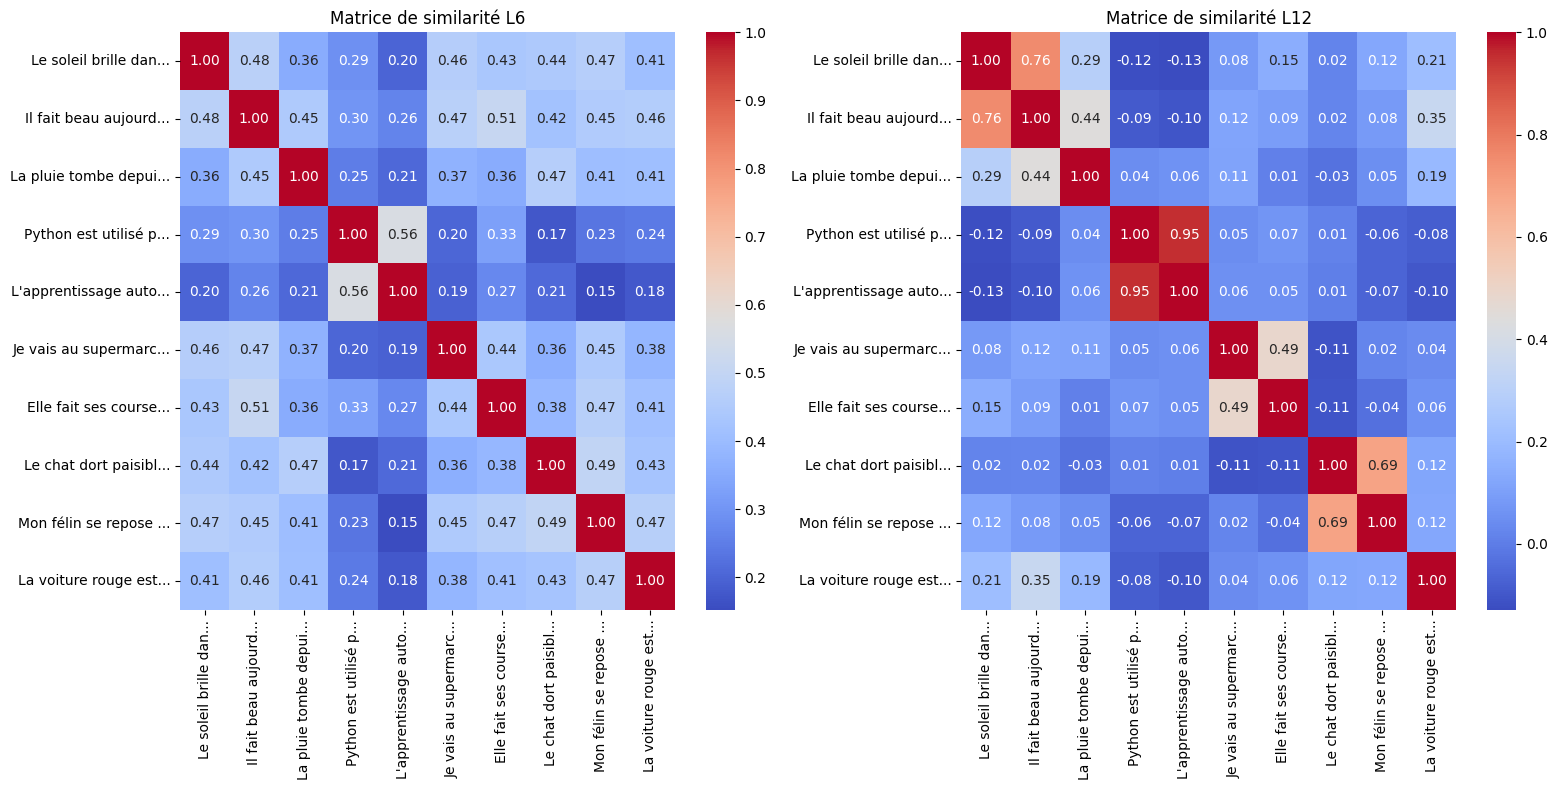

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(
    similarity_matrix_l6,
    annot=True,
    fmt="0.2f",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax1,
)
ax1.set_title("Matrice de similarité L6")

sns.heatmap(
    similarity_matrix_l12,
    annot=True,
    fmt="0.2f",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax2,
)
ax2.set_title("Matrice de similarité L12")

plt.tight_layout()
plt.show()

### Tâche 5.2 : Analyse comparative

Répondez aux questions suivantes :

1. Quelles sont les différences de scores entre les deux modèles ?
2. Quel modèle semble mieux capturer les similarités sémantiques en français ?
3. Y a-t-il une différence de temps d'exécution ?

In [50]:
# TODO : Votre analyse ici (en commentaires ou markdown)

# 1. Le modèle L6 donne des scores de similarité compris entre 0.19 et 0.56 tandis que le modèle L12 donne des scores entre -0.13 et 0.95.
# 2. Le modèle L12 semble mieux capturer les sémantiques en français.
# Par exmemple les phrases 'Python est utilisé pour le machine learning' et 'Le soleil brille dans le ciel' ont un score de similarité de -0.12 avec le modèle L12,
# tandis qu'avec le modèle L6, le score de similarité est de 0.29.
# De même les phrases 'L'apprentissage automatique utilise souvent Python' et 'Python est utilisé pour le machine learning' ont un score de 0.95 avec L12
# et 0.56 avec L6.
# 3. Le modèle L12 est légérement plus long que le modèle L6.